In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [19]:
## Scoring Formula:- Score = {mean * sr^2 / sr^2 + 1 : mean >=0 }                           {otherwise mean}

In [15]:
# Mean :- How much Pnl you make on average 
trade_pnl = [-100, -200, -50, 400]
print(np.mean(trade_pnl))

trade_pnl2 = [100, 50, 90, 200, -1000]
print(np.mean(trade_pnl2))

12.5
-112.0


In [16]:
# Standerd Deviation:- How stable is your Pnl
top_leaderboard_trades = [100, 101, 99, 98, 102]
print(np.mean(top_leaderboard_trades), np.std(top_leaderboard_trades))

bottom_leaderboard_trades = [200, -101, 99, 99, 203]
print(np.mean(bottom_leaderboard_trades), np.std(bottom_leaderboard_trades))

100.0 1.4142135623730951
100.0 110.46447392714093


In [17]:
#### Sharpe_ratio
def sharpe_ratio(pnls):
    return np.mean(pnls)/np.std(pnls)

sharpe_ratio(top_leaderboard_trades), sharpe_ratio(bottom_leaderboard_trades)

(70.71067811865474, 0.9052684220083012)

In [21]:
##### Annualized sharpe ratio
def annualized_sharpe_ratio(pnls):
    return np.sqrt(252) * sharpe_ratio(pnls)

In [22]:
df = pd.read_csv('https://raw.githubusercontent.com/UNSW-FinTech-Society-IT/algothon26-starter-code/refs/heads/main/prices.txt', sep=r'\s+')
df

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,147.56,65.20,36.85,69.75,95.73,2.38,32.11,103.46,52.80,10.34,...,36.56,74.55,35.89,8.03,27.81,46.43,29.42,33.02,38.25,81.78
1996,146.59,63.82,37.59,69.07,94.35,2.32,32.53,103.21,53.92,10.13,...,36.01,73.32,35.98,8.26,27.12,45.00,30.43,33.18,38.59,78.43
1997,147.28,63.54,37.11,70.00,94.31,2.38,32.81,105.06,53.98,10.20,...,36.33,73.66,36.14,8.25,26.99,44.79,30.55,33.53,39.61,79.76
1998,147.95,63.47,37.84,71.63,91.29,2.46,33.46,105.04,53.99,10.44,...,36.85,74.88,35.88,8.24,27.80,45.54,31.06,33.10,39.36,79.52


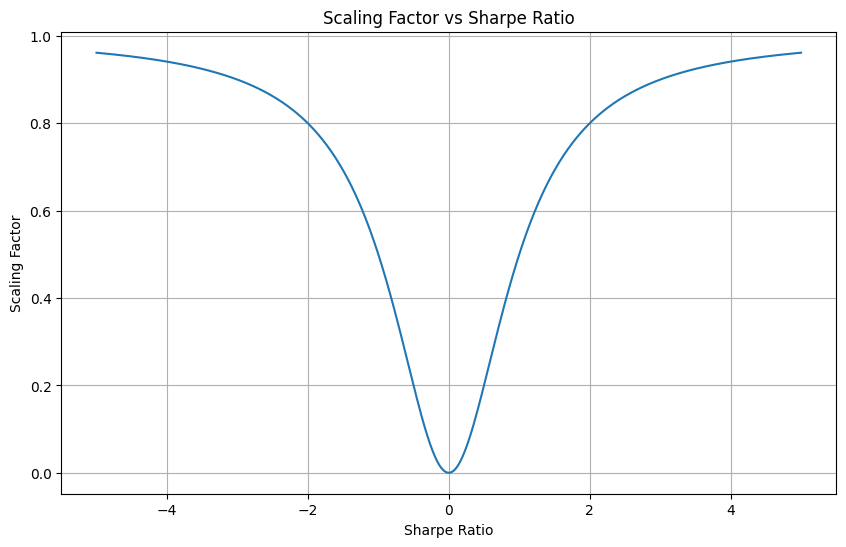

In [28]:
import matplotlib.pyplot as plt

def scaling_factor(sharpe_ratio):
    return sharpe_ratio ** 2 / (sharpe_ratio ** 2 + 1)

sharpe_ratios = np.linspace(-5, 5, 500)
scaling_factors = scaling_factor(sharpe_ratios)

plt.figure(figsize=(10, 6))
plt.plot(sharpe_ratios, scaling_factors)
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scaling Factor")
plt.title("Scaling Factor vs Sharpe Ratio")
plt.grid(True)
plt.show()

In [29]:
def scoring(pnl):
    return np.mean(pnl) * scaling_factor(annualized_sharpe_ratio(pnl))

In [30]:
trade_pnl3 = np.array([-100, -200, -50, 400])
scoring(trade_pnl3)

5.32994923857868

In [31]:
scoring(10 * trade_pnl3)

53.2994923857868

#### What is Predict
###### 1.Future Price
###### 2.Future Price Delta
###### 3.Future Price Return
###### 4.Future Price Log Return

In [35]:
tick_ahead = 7
df['ALGO_future_price'] = df['ALGO'].shift(-tick_ahead)
df[['ALGO','ALGO_future_price']].dropna()

df['ALGO_future_price_delta'] = df['ALGO_future_price'] - df['ALGO']
df[['ALGO', 'ALGO_future_price', 'ALGO_future_price_delta']]

df['ALGO_future_price_return'] = df['ALGO_future_price_delta'] / df['ALGO']
df[['ALGO','ALGO_future_price','ALGO_future_price_delta','ALGO_future_price_return']].dropna()

,ALGO,ALGO_future_price,ALGO_future_price_delta,ALGO_future_price_return
0,100.00,99.86,-0.14,-0.001400
1,98.49,98.91,0.42,0.004264
2,97.83,98.97,1.14,0.011653
3,98.02,100.22,2.20,0.022444
4,99.13,101.98,2.85,0.028750
...,...,...,...,...
1988,151.15,147.56,-3.59,-0.023751
1989,152.06,146.59,-5.47,-0.035973
1990,149.86,147.28,-2.58,-0.017216
1991,147.80,147.95,0.15,0.001015


Position Sizing:-
ALGO = $100K
REST = $10K

Transaction Fees:-
ALGO = 0.00002(0.2 basis points)
Rest = 0.00001(1.0 basis point)

key_points:-
1.Increase trade sizing because it's not using returns
2.Focus on ALGO because you can trade up to $100k and the fees are so low.

In [36]:
assets = list(df.columns)
assets

['ALGO',
 'AENO',
 'LSST',
 'SRNA',
 'ELLT',
 'AMRP',
 'OTCS',
 'HETT',
 'HUXZ',
 'DUCT',
 'SMAH',
 'NPCK',
 'MSDP',
 'EORC',
 'CUBO',
 'HRET',
 'ANSO',
 'DIHO',
 'RTTH',
 'SPLZ',
 'NWIG',
 'MMBT',
 'MDGI',
 'AGVF',
 'RRES',
 'CTGI',
 'ALUT',
 'ACAC',
 'SRTX',
 'GARI',
 'RCRI',
 'ACIX',
 'CCNS',
 'MTNS',
 'IHOZ',
 'NAYO',
 'FWWG',
 'EELT',
 'HRND',
 'AETS',
 'ULXY',
 'BLBT',
 'BENI',
 'ITPA',
 'HTRK',
 'NGTE',
 'ILVX',
 'FCSG',
 'FARS',
 'MHRM',
 'EAFC',
 'ALGO_future_price',
 'ALGO_futur_price_delta',
 'ALGO_future_price_delta',
 'ALGO_future_price_return']

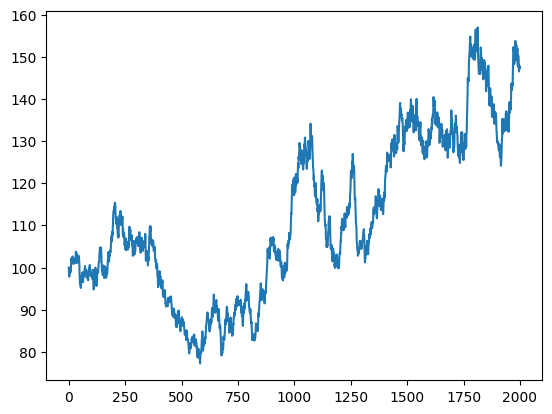

In [37]:
def plot_asset_timeseries(df, symbol):
    time_series = df[symbol]
    time_series.plot()

plot_asset_timeseries(df, 'ALGO')

## Why it's hard to predict this 
### Auto-Correlation Matrix

In [38]:
df['ALGO_return'] = df['ALGO'].pct_change()
df['ALGO_return_lag_1'] = df['ALGO_return'].shift()
df['ALGO_return_lag_2'] = df['ALGO_return'].shift(2)

df[['ALGO_return', 'ALGO_return_lag_1', 'ALGO_return_lag_2']].corr()

,ALGO_return,ALGO_return_lag_1,ALGO_return_lag_2
ALGO_return,1.000000,0.029169,-0.019782
ALGO_return_lag_1,0.029169,1.000000,0.029246
ALGO_return_lag_2,-0.019782,0.029246,1.000000


In [39]:
df

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,FARS,MHRM,EAFC,ALGO_future_price,ALGO_futur_price_delta,ALGO_future_price_delta,ALGO_future_price_return,ALGO_return,ALGO_return_lag_1,ALGO_return_lag_2
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,66.43,22.41,45.08,99.86,-0.14,-0.14,-0.001400,NaN,NaN,NaN
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,64.66,22.10,44.28,98.91,0.42,0.42,0.004264,-0.015100,NaN,NaN
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,64.19,20.87,45.30,98.97,1.14,1.14,0.011653,-0.006701,-0.015100,NaN
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,62.80,20.95,46.32,100.22,2.20,2.20,0.022444,0.001942,-0.006701,-0.015100
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,63.94,20.72,45.56,101.98,2.85,2.85,0.028750,0.011324,0.001942,-0.006701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,147.56,65.20,36.85,69.75,95.73,2.38,32.11,103.46,52.80,10.34,...,33.02,38.25,81.78,NaN,NaN,NaN,NaN,-0.014690,-0.003990,-0.000199
1996,146.59,63.82,37.59,69.07,94.35,2.32,32.53,103.21,53.92,10.13,...,33.18,38.59,78.43,NaN,NaN,NaN,NaN,-0.006574,-0.014690,-0.003990
1997,147.28,63.54,37.11,70.00,94.31,2.38,32.81,105.06,53.98,10.20,...,33.53,39.61,79.76,NaN,NaN,NaN,NaN,0.004707,-0.006574,-0.014690
1998,147.95,63.47,37.84,71.63,91.29,2.46,33.46,105.04,53.99,10.44,...,33.10,39.36,79.52,NaN,NaN,NaN,NaN,0.004549,0.004707,-0.006574


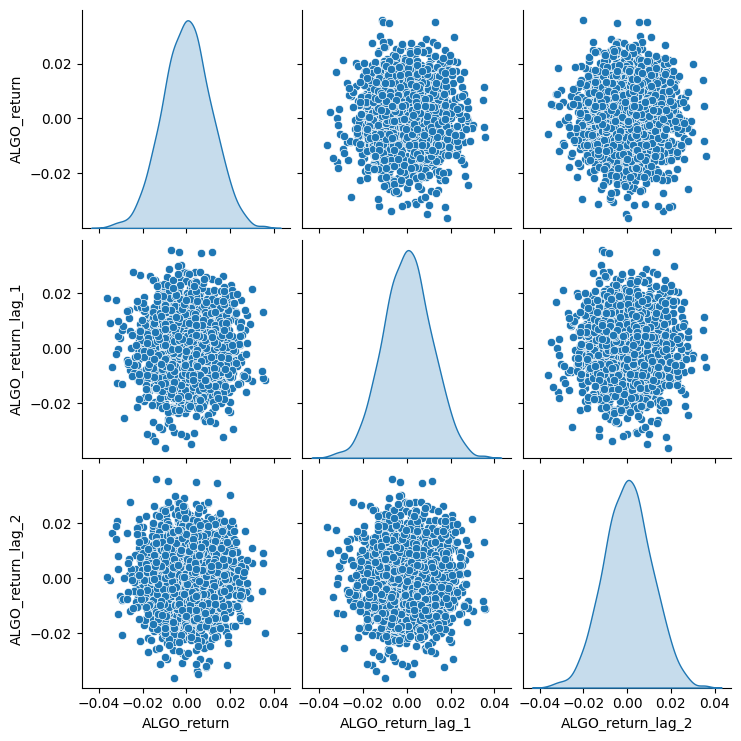

In [40]:
import seaborn as sns 
sns.pairplot(df[['ALGO_return', 'ALGO_return_lag_1', 'ALGO_return_lag_2']], diag_kind='kde')

In [41]:
#### Magnitude of Price Movement Research
forecast_horizon = 10
df['ALGO_delta'] = df['ALGO'].shift(-forecast_horizon) - df['ALGO']
df['ALGO_abs_delta'] = df['ALGO_delta'].abs()
df['ALGO_abs_delta'].describe()

count    1990.000000
mean        3.074583
std         2.588857
min         0.000000
25%         1.092500
50%         2.430000
75%         4.350000
max        16.470000
Name: ALGO_abs_delta, dtype: float64

In [42]:
forecast_horizon = 2
df['ALGO_delta'] = df['ALGO'].shift(-forecast_horizon) - df['ALGO']
df['ALGO_abs_delta'] = df['ALGO_delta'].abs()
df['ALGO_abs_delta'].describe()

count    1998.000000
mean        1.410075
std         1.133827
min         0.000000
25%         0.510000
50%         1.150000
75%         2.007500
max         7.160000
Name: ALGO_abs_delta, dtype: float64

In [43]:
forecast_horizon = 30
df['ALGO_delta'] = df['ALGO'].shift(-forecast_horizon) - df['ALGO']
df['ALGO_abs_delta'] = df['ALGO_delta'].abs()
df['ALGO_abs_delta'].describe()

count    1970.000000
mean        5.439533
std         4.487331
min         0.000000
25%         2.030000
50%         4.325000
75%         7.957500
max        29.330000
Name: ALGO_abs_delta, dtype: float64

#### Create Trding strategy
1. Create a model to predict a future price
2. Create a strategy based on my model's predictions

In [44]:
forecast_horizon = 30

In [45]:
new_cols = {}
for asset in assets:
    new_cols[f'{asset}_future_price'] = df[asset].shift(-forecast_horizon)
    new_cols[f'{asset}_return']       = (df[asset].shift(-forecast_horizon) - df[asset]) / df[asset]
    new_cols[f'{asset}_return_lag_1'] = new_cols[f'{asset}_return'].shift(forecast_horizon)

returns = pd.DataFrame(new_cols).dropna()
returns

,ALGO_future_price,ALGO_return,ALGO_return_lag_1,AENO_future_price,AENO_return,AENO_return_lag_1,LSST_future_price,LSST_return,LSST_return_lag_1,SRNA_future_price,...,ALGO_future_price_return_lag_1,ALGO_futur_price_delta_future_price,ALGO_futur_price_delta_return,ALGO_futur_price_delta_return_lag_1,ALGO_future_price_delta_future_price,ALGO_future_price_delta_return,ALGO_future_price_delta_return_lag_1,ALGO_future_price_return_future_price,ALGO_future_price_return_return,ALGO_future_price_return_return_lag_1
30,98.06,-0.038816,0.020200,100.29,-0.140175,0.001116,102.34,-0.152534,0.063496,113.02,...,0.018726,0.86,-3.965517,1.071429,0.86,-3.965517,1.071429,0.008770,-4.085275,1.030414
31,98.87,-0.043810,0.049853,99.76,-0.155864,0.046396,104.14,-0.152092,0.072383,115.35,...,0.031342,-0.50,-0.640288,-4.309524,-0.50,-0.640288,-4.309524,-0.005057,-0.623807,-4.152369
32,97.69,-0.058863,0.061024,99.58,-0.181018,0.078882,100.30,-0.168049,0.074797,112.57,...,0.027584,1.06,-1.504762,-2.842105,1.06,-1.504762,-2.842105,0.010851,-1.536332,-2.736158
33,96.51,-0.060090,0.047541,100.57,-0.174302,0.084981,101.29,-0.159837,0.038505,114.33,...,0.021353,2.81,-9.781250,-1.145455,2.81,-9.781250,-1.145455,0.029116,-10.342646,-1.138853
34,97.38,-0.058494,0.043377,101.60,-0.152698,0.055639,101.05,-0.177519,0.027429,114.45,...,-0.005295,2.77,-2.391960,-1.698246,2.77,-2.391960,-1.698246,0.028445,-2.478439,-1.669217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1958,151.15,0.091651,0.030745,62.24,0.190740,-0.036853,32.36,-0.080421,-0.066826,69.84,...,0.059753,-3.59,-1.949735,-35.363636,-3.59,-1.949735,-35.363636,-0.023751,-1.869999,-34.338634
1959,152.06,0.105007,0.017901,64.49,0.217711,-0.021615,33.73,-0.039031,-0.120301,70.40,...,0.068563,-5.47,-1.876603,-11.947368,-5.47,-1.876603,-11.947368,-0.035973,-1.793301,-11.754849
1960,149.86,0.083978,0.044579,65.85,0.208700,0.043079,34.52,-0.013432,-0.107170,70.31,...,0.054659,-2.58,-1.524390,0.447059,-2.58,-1.524390,0.447059,-0.017216,-1.483765,0.385304
1961,147.80,0.043491,0.068497,65.34,0.178784,0.074641,33.62,-0.090614,-0.033969,69.79,...,0.054499,0.15,-0.940239,-0.393720,0.15,-0.940239,-0.393720,0.001015,-0.942730,-0.432586


In [46]:
returns[['ALGO_return'] + [f'{asset}_return_lag_1' for asset in assets]].corr()

,ALGO_return,ALGO_return_lag_1,AENO_return_lag_1,LSST_return_lag_1,SRNA_return_lag_1,ELLT_return_lag_1,AMRP_return_lag_1,OTCS_return_lag_1,HETT_return_lag_1,HUXZ_return_lag_1,...,NGTE_return_lag_1,ILVX_return_lag_1,FCSG_return_lag_1,FARS_return_lag_1,MHRM_return_lag_1,EAFC_return_lag_1,ALGO_future_price_return_lag_1,ALGO_futur_price_delta_return_lag_1,ALGO_future_price_delta_return_lag_1,ALGO_future_price_return_return_lag_1
ALGO_return,1.000000,0.012371,-0.106817,0.051715,0.091577,-0.017818,-0.177617,-0.054383,-0.134619,-0.143946,...,-0.031172,-0.061216,-0.172576,-0.014130,-0.177386,-0.056177,0.211917,0.027671,0.027671,0.027328
ALGO_return_lag_1,0.012371,1.000000,0.463530,0.484980,0.424398,0.453260,0.394746,0.501307,0.517674,0.438061,...,0.515432,0.525955,0.271571,0.288175,0.541906,0.530688,0.770147,-0.050447,-0.050447,-0.046965
AENO_return_lag_1,-0.106817,0.463530,1.000000,0.233515,0.411136,0.286628,0.334913,0.268856,0.330693,0.319991,...,0.325757,0.307010,0.188256,0.264954,0.471989,0.397642,0.310763,0.003809,0.003809,0.004691
LSST_return_lag_1,0.051715,0.484980,0.233515,1.000000,0.306497,0.102620,0.135059,0.299086,0.291111,0.284923,...,0.251752,0.389506,0.106336,0.206113,0.197921,0.189984,0.361495,-0.020960,-0.020960,-0.019305
SRNA_return_lag_1,0.091577,0.424398,0.411136,0.306497,1.000000,0.269199,0.133958,0.301773,0.243118,0.332543,...,0.468932,0.476254,-0.024882,0.150165,0.299148,0.290062,0.293506,-0.010054,-0.010054,-0.009077
ELLT_return_lag_1,-0.017818,0.453260,0.286628,0.102620,0.269199,1.000000,0.268344,0.304016,0.120343,0.204890,...,0.292611,0.209440,0.250108,-0.029618,0.401048,0.341738,0.325689,-0.010908,-0.010908,-0.009200
AMRP_return_lag_1,-0.177617,0.394746,0.334913,0.135059,0.133958,0.268344,1.000000,0.280680,0.280131,0.199624,...,0.222114,0.225369,0.115457,0.024448,0.335249,0.211487,0.277037,-0.031219,-0.031219,-0.031517
OTCS_return_lag_1,-0.054383,0.501307,0.268856,0.299086,0.301773,0.304016,0.280680,1.000000,0.382907,0.235081,...,0.334598,0.309574,0.027489,0.075424,0.258081,0.174041,0.381191,-0.007015,-0.007015,-0.006407
HETT_return_lag_1,-0.134619,0.517674,0.330693,0.291111,0.243118,0.120343,0.280131,0.382907,1.000000,0.243764,...,0.329233,0.428561,-0.041069,0.164598,0.297318,0.186246,0.343971,0.002521,0.002521,0.003861
HUXZ_return_lag_1,-0.143946,0.438061,0.319991,0.284923,0.332543,0.204890,0.199624,0.235081,0.243764,1.000000,...,0.366915,0.343975,0.141641,0.032290,0.317186,0.375350,0.299837,0.001273,0.001273,0.003668


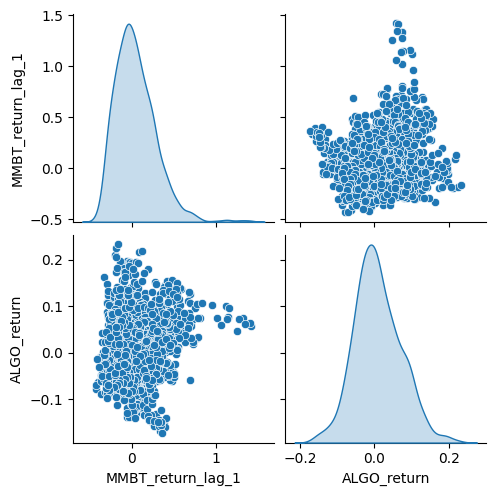

In [47]:
feature = 'MMBT_return_lag_1'
sns.pairplot(returns[[feature, 'ALGO_return']], diag_kind='kde')

In [48]:
## Use First Order Approximation
## Use linear model to approximate because there only 500 data points: less change to overfit.
##  y = w * x + b


In [49]:
i = int(len(returns) * 0.69)
train_df = returns.iloc[:i].copy()
test_df  = returns.iloc[i:].copy()

In [50]:
train_df

,ALGO_future_price,ALGO_return,ALGO_return_lag_1,AENO_future_price,AENO_return,AENO_return_lag_1,LSST_future_price,LSST_return,LSST_return_lag_1,SRNA_future_price,...,ALGO_future_price_return_lag_1,ALGO_futur_price_delta_future_price,ALGO_futur_price_delta_return,ALGO_futur_price_delta_return_lag_1,ALGO_future_price_delta_future_price,ALGO_future_price_delta_return,ALGO_future_price_delta_return_lag_1,ALGO_future_price_return_future_price,ALGO_future_price_return_return,ALGO_future_price_return_return_lag_1
30,98.06,-0.038816,0.020200,100.29,-0.140175,0.001116,102.34,-0.152534,0.063496,113.02,...,0.018726,0.86,-3.965517,1.071429,0.86,-3.965517,1.071429,0.008770,-4.085275,1.030414
31,98.87,-0.043810,0.049853,99.76,-0.155864,0.046396,104.14,-0.152092,0.072383,115.35,...,0.031342,-0.50,-0.640288,-4.309524,-0.50,-0.640288,-4.309524,-0.005057,-0.623807,-4.152369
32,97.69,-0.058863,0.061024,99.58,-0.181018,0.078882,100.30,-0.168049,0.074797,112.57,...,0.027584,1.06,-1.504762,-2.842105,1.06,-1.504762,-2.842105,0.010851,-1.536332,-2.736158
33,96.51,-0.060090,0.047541,100.57,-0.174302,0.084981,101.29,-0.159837,0.038505,114.33,...,0.021353,2.81,-9.781250,-1.145455,2.81,-9.781250,-1.145455,0.029116,-10.342646,-1.138853
34,97.38,-0.058494,0.043377,101.60,-0.152698,0.055639,101.05,-0.177519,0.027429,114.45,...,-0.005295,2.77,-2.391960,-1.698246,2.77,-2.391960,-1.698246,0.028445,-2.478439,-1.669217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,114.25,0.008652,0.085794,59.28,-0.072010,0.005668,91.71,-0.026433,-0.042196,81.06,...,0.041922,0.81,-1.870968,-1.265714,0.81,-1.870968,-1.265714,0.007090,-1.863497,-1.244719
1359,115.11,0.008675,0.077620,60.73,-0.061650,0.024213,91.56,-0.052566,-0.014581,82.54,...,0.026466,1.42,-1.586777,-1.828767,1.42,-1.586777,-1.828767,0.012336,-1.581730,-1.769071
1360,116.28,-0.005559,0.100103,60.84,-0.072844,0.050424,90.68,-0.084872,-0.038521,83.31,...,0.030652,0.62,-1.144522,-2.430000,0.62,-1.144522,-2.430000,0.005332,-1.145330,-2.299878
1361,115.62,-0.010950,0.101998,60.39,-0.091743,0.064862,91.65,-0.073587,-0.029337,84.36,...,0.045363,0.31,-1.119231,-1.797546,0.31,-1.119231,-1.797546,0.002681,-1.120551,-1.723727


In [51]:
test_df

,ALGO_future_price,ALGO_return,ALGO_return_lag_1,AENO_future_price,AENO_return,AENO_return_lag_1,LSST_future_price,LSST_return,LSST_return_lag_1,SRNA_future_price,...,ALGO_future_price_return_lag_1,ALGO_futur_price_delta_future_price,ALGO_futur_price_delta_return,ALGO_futur_price_delta_return_lag_1,ALGO_future_price_delta_future_price,ALGO_future_price_delta_return,ALGO_future_price_delta_return_lag_1,ALGO_future_price_return_future_price,ALGO_future_price_return_return,ALGO_future_price_return_return_lag_1
1363,112.76,-0.019393,0.065610,58.77,-0.116905,0.023846,84.26,-0.115473,-0.099877,82.12,...,0.057968,3.80,4.277778,-0.506849,3.80,4.277778,-0.506849,0.033700,4.382154,-0.537213
1364,112.68,-0.002125,0.055031,58.15,-0.110448,0.001686,84.31,-0.079082,-0.109522,81.05,...,0.053764,5.00,0.607717,0.009740,5.00,0.607717,0.009740,0.044373,0.611141,-0.042929
1365,115.06,0.024212,0.041922,58.20,-0.126520,0.012922,84.36,-0.082146,-0.116844,82.53,...,0.056014,5.42,0.299760,0.661355,5.42,0.299760,0.661355,0.047106,0.269034,0.594510
1366,116.53,0.043241,0.026466,58.08,-0.112062,-0.001374,90.67,-0.023899,-0.109054,82.44,...,0.070281,4.89,-0.294372,2.430693,4.89,-0.294372,2.430693,0.041963,-0.323620,2.342238
1367,116.90,0.037820,0.030652,56.92,-0.107417,-0.039608,90.95,-0.035729,-0.099570,83.71,...,0.072812,4.58,-0.043841,27.176471,4.58,-0.043841,27.176471,0.039179,-0.078685,26.338481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1958,151.15,0.091651,0.030745,62.24,0.190740,-0.036853,32.36,-0.080421,-0.066826,69.84,...,0.059753,-3.59,-1.949735,-35.363636,-3.59,-1.949735,-35.363636,-0.023751,-1.869999,-34.338634
1959,152.06,0.105007,0.017901,64.49,0.217711,-0.021615,33.73,-0.039031,-0.120301,70.40,...,0.068563,-5.47,-1.876603,-11.947368,-5.47,-1.876603,-11.947368,-0.035973,-1.793301,-11.754849
1960,149.86,0.083978,0.044579,65.85,0.208700,0.043079,34.52,-0.013432,-0.107170,70.31,...,0.054659,-2.58,-1.524390,0.447059,-2.58,-1.524390,0.447059,-0.017216,-1.483765,0.385304
1961,147.80,0.043491,0.068497,65.34,0.178784,0.074641,33.62,-0.090614,-0.033969,69.79,...,0.054499,0.15,-0.940239,-0.393720,0.15,-0.940239,-0.393720,0.001015,-0.942730,-0.432586


In [52]:
model    = LinearRegression()
features = [feature]
target   = 'ALGO_return'

model.fit(train_df[features], train_df[target])

LinearRegression()

In [53]:
model.coef_, model.intercept_

(array([0.04434936]), 0.0025179568474022543)

### Backtest